# Challenge Overview

Build machine learning (ML) models to detect misinformation in Portuguese news articles, and
leverage interpretability and explainability methods to analyze results on the FakeNews-PT
dataset.

# 1 Model Training & Evaluation (10 points)

a) Extract TF-IDF features from the text with a maximum number of features (terms) set to 5000.
Make sure to add smoothing for out-of-vocabulary (OOV) words (idf smoothing). Define the
minimum and maximum number of documents a term must appear in as min_df=10, and the
maximum proportion of documents a term can appear in as max_df=0.9.

Imports for the project:

In [28]:
# Feature selection through Tfidfvectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Metrics and Kfold
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

# Pipeline 
from sklearn.pipeline import make_pipeline

# Permutations
from sklearn.inspection import permutation_importance

# Model Selection 
from sklearn.model_selection import GridSearchCV

# Required models
from sklearn.tree import DecisionTreeClassifier 
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# distances
from sklearn.metrics.pairwise import cosine_distances

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Numerical Computing
import numpy as np

# import spacy
import spacy
#nlp = spacy.load("pt_core_news_lg")

import nltk

# Lime
from lime.lime_text import LimeTextExplainer

In [29]:
from nltk.corpus import stopwords
PORTUGUESE_STOPWORDS = stopwords.words('portuguese')

RANDOM_STATE = 42

Train, Validation and Test datasets without preprocessing

In [30]:
# Obtain all the text documents as a pandas data frame (train, validation and test)
train_fake_news_df = pd.read_csv("../data/train.csv")
val_fake_news_df = pd.read_csv("../data/val.csv")
test_fake_news_df = pd.read_csv("../data/test.csv")

Lemmatization of the datasets

In [14]:
# Lemmatize texts
#def lemmatize_text(text):
#    doc = nlp(text)
#    lemmatized_tokens = [token.lemma_ for token in doc if not (token.is_punct or token.is_space or token.is_digit)]
#    return " ".join(lemmatized_tokens)

#train_fake_news_df['Text'] = train_fake_news_df['Text'].apply(lemmatize_text)
#val_fake_news_df['Text'] = val_fake_news_df['Text'].apply(lemmatize_text)
#test_fake_news_df['Text'] = test_fake_news_df['Text'].apply(lemmatize_text)

In [15]:
# Save lemmatized data to a csv file
#train_fake_news_df.to_csv("../data/train_lemmatized.csv", index=False, encoding="utf-8")
#val_fake_news_df.to_csv("../data/val_lemmatized.csv", index=False, encoding="utf-8")
#test_fake_news_df.to_csv("../data/test_lemmatized.csv", index=False, encoding="utf-8")

Separate Texts from their labels

In [31]:
# Separate text documents from their labels (train, validation and test)
train_news_texts = train_fake_news_df['Text']
train_news_labels = train_fake_news_df['Label']

val_news_texts = val_fake_news_df['Text']
val_news_labels = val_fake_news_df['Label']

test_news_texts = test_fake_news_df['Text']
test_news_labels = test_fake_news_df['Label']

print("News Texts:\n")
print(train_news_texts)
print("\nNews Labels:\n")
print(train_news_labels)

News Texts:

0        PJ em operação internacional de tráfico de dro...
1        O texto foi criado - numa universidade da Repú...
2        Nunca pague multas por conduzir sem carta ou s...
3        Depois de António Guterres, uma estátua de D. ...
4        O MAR, uma droga gratuita que cura pelo menos ...
                               ...                        
50582    FMI recomenda reforma para evitar "acumulação ...
50583    Governo diz que o estado vai indemnizar as vít...
50584    Homem com cancro terminal realiza último desej...
50585    Grupo Impresa tem dívida de 189,1 milhões de e...
50586    Mãe fica chocada ao perceber quem estava a seg...
Name: Text, Length: 50587, dtype: object

News Labels:

0        1
1        1
2        0
3        0
4        0
        ..
50582    1
50583    0
50584    0
50585    0
50586    0
Name: Label, Length: 50587, dtype: int64


Apply TF-IDF algorithm

In [32]:
# Characteristics of the tf_idf feature selection that were requested
MAX_FEATURES = 5000
MIN_DF = 10
MAX_DF = 0.9
SMOOTH_IDF = True
STOP_WORDS = PORTUGUESE_STOPWORDS

# Optional characteristics that improve feature selection
LOWER_CASE = True


# Tf-idf vectorizer initialization
tfidf_vectorizer = TfidfVectorizer(
    max_features= MAX_FEATURES,
    min_df= MIN_DF,
    max_df= MAX_DF,
    smooth_idf= SMOOTH_IDF,
    stop_words= STOP_WORDS,
    lowercase= LOWER_CASE
)

In [33]:
# Obtain the matrix of df and idf frequencies for training
train_tfidf = tfidf_vectorizer.fit_transform(train_news_texts)

# Get the name of the features that were determined
feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", train_tfidf.shape)
print("Exemplo de termos:", feature_names[:20])
train_tfidf

TF-IDF matrix shape: (50587, 5000)
Exemplo de termos: ['00' '000' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '100' '11'
 '110' '116' '12' '120' '125' '13']


<50587x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 5096070 stored elements in Compressed Sparse Row format>

In [34]:
# Transform the validation and testing data
val_tfidf = tfidf_vectorizer.transform(val_news_texts)
test_tfidf = tfidf_vectorizer.transform(test_news_texts)

Same for the lemmatized datasets

In [35]:
train_fake_news_df_lemmatized= pd.read_csv("../data/train_lemmatized.csv")
val_fake_news_df_lemmatized = pd.read_csv("../data/val_lemmatized.csv")
test_fake_news_df_lemmatized = pd.read_csv("../data/test_lemmatized.csv")

# Separate text documents from their labels (train, validation and test)
train_news_texts_lemmatized = train_fake_news_df_lemmatized['Text']
train_news_labels_lemmatized = train_fake_news_df_lemmatized['Label']

val_news_texts_lemmatized = val_fake_news_df_lemmatized['Text']
val_news_labels_lemmatized = val_fake_news_df_lemmatized['Label']

test_news_texts_lemmatized = test_fake_news_df_lemmatized['Text']
test_news_labels_lemmatized = test_fake_news_df_lemmatized['Label']

# Tf-idf vectorizer initialization
tfidf_vectorizer_lemmatized = TfidfVectorizer(
    max_features= MAX_FEATURES,
    min_df= MIN_DF,
    max_df= MAX_DF,
    smooth_idf= SMOOTH_IDF,
    stop_words= STOP_WORDS,
    lowercase= LOWER_CASE
)

train_tfidf_lemmatized = tfidf_vectorizer_lemmatized.fit_transform(train_news_texts_lemmatized)

# Transform the validation and testing data
val_tfidf_lemmatized = tfidf_vectorizer_lemmatized.transform(val_news_texts_lemmatized)
test_tfidf_lemmatized = tfidf_vectorizer_lemmatized.transform(test_news_texts_lemmatized)

b) Train the following models using 5-fold cross-validation, tune key hyperparameters systematically
(e.g., regularization strength λ, tree depth), and document your hyperparameter search process.
1) Decision Tree
2) Gaussian Naive Bayes
3) Logistic Regression with L2 regularization
4) Logistic Regression with L1 regularization
5) Multi-Layer Perceptron (MLP)

In [36]:
# KFold that will be used for All the models
K_FOLDS = 5
SHUFFLE = True

SKF = StratifiedKFold(n_splits= K_FOLDS, shuffle= SHUFFLE, random_state= RANDOM_STATE)

SCORING = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

In [45]:
def calculate_metrics(best_model, X_val, y_val, X_test, y_test) -> tuple[dict, dict]:
    """
    Perform hyperparameter tuning and evaluate model performance across datasets.
    
    This function fits a GridSearchCV or RandomizedSearchCV object on the training data,
    retrieves the best estimator, evaluates it on validation and test sets, and returns
    two dictionaries containing the performance metrics.
    
    Parameters
    ----------
    grid_search : GridSearchCV or RandomizedSearchCV
        Initialized search object with estimator, parameter grid/distributions, 
        cv strategy, and scoring metrics already configured.
    X_train : array-like of shape (n_samples, n_features)
        Training feature matrix (e.g., TF-IDF vectors).
    y_train : array-like of shape (n_samples,)
        Training target labels.
    X_val : array-like of shape (n_samples, n_features)
        Validation feature matrix.
    y_val : array-like of shape (n_samples,)
        Validation target labels.
    X_test : array-like of shape (n_samples, n_features)
        Test feature matrix.
    y_test : array-like of shape (n_samples,)
        Test target labels.
    
    Returns
    -------
    tuple[dict, dict]
        A tuple containing two dictionaries:
        - val_metrics: Validation set metrics (accuracy, precision, recall, f1)
        - test_metrics: Test set metrics (accuracy, precision, recall, f1)
    
    Side Effects
    ------------
    Prints to console:
        - Best model parameters
        - Validation set metrics
        - Test set metrics
    
    """
    
    # Validation set predictions and metrics
    y_val_pred = best_model.predict(X_val)
    val_metrics = {
        'Dataset': ['Validation'],
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred, average='weighted'),
        'Recall': recall_score(y_val, y_val_pred, average='weighted'),
        'F1-Score': f1_score(y_val, y_val_pred, average='weighted')
    }
    
    print("\nValidation metrics:\n")
    print(f"Accuracy:  {val_metrics['Accuracy']:.4f}")
    print(f"Precision: {val_metrics['Precision']:.4f}")
    print(f"Recall:    {val_metrics['Recall']:.4f}")
    print(f"F1-Score:  {val_metrics['F1-Score']:.4f}")
    
    # Test set predictions and metrics
    y_test_pred = best_model.predict(X_test)
    test_metrics = {
        'Dataset': ['Test'],
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall': recall_score(y_test, y_test_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_test_pred, average='weighted')
    }
    
    print("\nTest metrics:\n")
    print(f"Accuracy:  {test_metrics['Accuracy']:.4f}")
    print(f"Precision: {test_metrics['Precision']:.4f}")
    print(f"Recall:    {test_metrics['Recall']:.4f}")
    print(f"F1-Score:  {test_metrics['F1-Score']:.4f}")
    
    return val_metrics, test_metrics

In [46]:
def train_best_model(grid_search, X_train, y_train):
    grid_search.fit(X_train, y_train)
    print("\nBest Parameters:\n")
    print(grid_search.best_params_, "\n")

    return grid_search.best_estimator_

Decision Tree

In [47]:
# Define a hyperparameter tuning algorithm for decision tree
def decision_tree_parameters_grid_search(max_depth: list,
                                       min_samples_split: list,
                                       min_samples_leaf: list,
                                       max_features: int,
                                       random_state: int,
                                       class_weight: list,
                                       criteria: str,
                                       skf: StratifiedKFold,
                                       scoring_dict: dict) -> GridSearchCV:

   # Param grid for Decision Tree 
   param_grid = {
      'max_depth': max_depth,  
      'min_samples_split': min_samples_split,     
      'min_samples_leaf': min_samples_leaf,
      'class_weight': class_weight  
   }
    
   # Initialize Decision Tree Classifier
   decision_tree_model = DecisionTreeClassifier(
      max_features=max_features,
      random_state=random_state
   )
   
   # Search for the best set of parameters that optimize the model based on criteria
   grid_search = GridSearchCV(
      estimator=decision_tree_model,
      param_grid=param_grid,
      cv=skf,
      scoring=scoring_dict,
      refit=criteria,
      n_jobs=-1  # Add this for parallel processing
   )
   
   return grid_search

In [48]:
# Decision Tree
    
# Parameters
max_depth = [10, 30, 50]
min_samples_split = [2, 5, 10, 20]
min_samples_leaf = [1, 2, 4]
class_weight = [None, 'balanced']

CRITERIA = "f1"

# find best parameters
decision_tree_grid_search = decision_tree_parameters_grid_search(
    max_depth = max_depth,
    min_samples_split = min_samples_split,
    min_samples_leaf = min_samples_leaf,
    max_features = MAX_FEATURES,
    random_state = RANDOM_STATE,
    class_weight = class_weight,
    criteria = CRITERIA ,
    skf = SKF,
    scoring_dict=SCORING
)

best_decision_tree_model = train_best_model(decision_tree_grid_search, train_tfidf, train_news_labels)

decision_tree_metrics = calculate_metrics(
    best_model=best_decision_tree_model,
    X_val=val_tfidf,
    y_val=val_news_labels,
    X_test=test_tfidf,
    y_test=test_news_labels
)

decision_tree_metrics


Best Parameters:

{'class_weight': 'balanced', 'max_depth': 50, 'min_samples_leaf': 1, 'min_samples_split': 2} 


Validation metrics:

Accuracy:  0.8506
Precision: 0.8517
Recall:    0.8506
F1-Score:  0.8505

Test metrics:

Accuracy:  0.8531
Precision: 0.8535
Recall:    0.8531
F1-Score:  0.8531


({'Dataset': ['Validation'],
  'Accuracy': 0.8505692599620494,
  'Precision': 0.8517261202826049,
  'Recall': 0.8505692599620494,
  'F1-Score': 0.8504799373910794},
 {'Dataset': ['Test'],
  'Accuracy': 0.8530993042378242,
  'Precision': 0.8534638208237071,
  'Recall': 0.8530993042378242,
  'F1-Score': 0.8530550238011914})

In [57]:
# Decision tree with lemmatized dataset
best_decision_tree_model_lemmatized = train_best_model(decision_tree_grid_search, train_tfidf_lemmatized, train_news_labels)

decision_tree_metrics_lemmatized = calculate_metrics(
    best_model=best_decision_tree_model_lemmatized,
    X_val=val_tfidf_lemmatized,
    y_val=val_news_labels_lemmatized,
    X_test=test_tfidf_lemmatized,
    y_test=test_news_labels_lemmatized
)

decision_tree_metrics_lemmatized


Best Parameters:

{'class_weight': 'balanced', 'max_depth': 50, 'min_samples_leaf': 1, 'min_samples_split': 5} 


Validation metrics:

Accuracy:  0.9640
Precision: 0.9643
Recall:    0.9640
F1-Score:  0.9640

Test metrics:

Accuracy:  0.9640
Precision: 0.9643
Recall:    0.9640
F1-Score:  0.9640


({'Dataset': ['Validation'],
  'Accuracy': 0.9640026093660427,
  'Precision': 0.9643189593031842,
  'Recall': 0.9640026093660427,
  'F1-Score': 0.9639980989273934},
 {'Dataset': ['Test'],
  'Accuracy': 0.9640026093660427,
  'Precision': 0.9643189593031842,
  'Recall': 0.9640026093660427,
  'F1-Score': 0.9639980989273934})

Guassian Naive Bayes

In [58]:
def get_gaussian_NB_best_model(var_smoothing_values:list,
                       X_train,
                       y_train,
                       X_val,
                       y_val):
    # Store results for each parameter value
    results = []

    print("Tuning var_smoothing parameter for Gaussian Naive Bayes...\n")

    for var_smooth in var_smoothing_values:
        # Initialize and train model
        model = GaussianNB(var_smoothing=var_smooth)
        model.fit(X_train, y_train)
        
        # Validation predictions and metrics
        y_val_pred = model.predict(X_val)
        val_f1 = f1_score(y_val, y_val_pred, average='weighted')
        
        results.append({
            'var_smoothing': var_smooth,
            'val_f1_score': val_f1,
            'model': model
        })
        
        print(f"var_smoothing={var_smooth:.0e} | Validation F1-Score: {val_f1:.4f}")

    # Find best model based on validation F1-score
    best_result = max(results, key=lambda x: x['val_f1_score'])
    best_model = best_result['model']

    return best_model


    """ print(f"Best Parameter: var_smoothing = {best_result['var_smoothing']:.0e}")
    print(f"Best Validation F1-Score: {best_result['val_f1_score']:.4f}")
    

    # Evaluate best model on validation and test sets
    y_val_pred = best_model.predict(X_val)
    val_metrics = {
        'Dataset': ['Validation'],
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred, average='weighted'),
        'Recall': recall_score(y_val, y_val_pred, average='weighted'),
        'F1-Score': f1_score(y_val, y_val_pred, average='weighted')
    }

    print("\nValidation Metrics:\n")
    print(f"Accuracy:  {val_metrics['Accuracy']:.4f}")
    print(f"Precision: {val_metrics['Precision']:.4f}")
    print(f"Recall:    {val_metrics['Recall']:.4f}")
    print(f"F1-Score:  {val_metrics['F1-Score']:.4f}")

    # Test set evaluation
    y_test_pred = best_model.predict(X_test)
    test_metrics = {
        'Dataset': ['Test'],
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall': recall_score(y_test, y_test_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_test_pred, average='weighted')
    }

    print("\nTest Metrics:\n")
    print(f"Accuracy:  {test_metrics['Accuracy']:.4f}")
    print(f"Precision: {test_metrics['Precision']:.4f}")
    print(f"Recall:    {test_metrics['Recall']:.4f}")
    print(f"F1-Score:  {test_metrics['F1-Score']:.4f}")

    # Combine results
    return (val_metrics, test_metrics) """

In [60]:
# Gaussian Naive Bayes - Manual hyperparameter tuning
VAR_SMOTHING_VALUES = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

# Convert sparse matrices to dense once (outside the loop).       
X_train_dense = train_tfidf.toarray()
X_val_dense = val_tfidf.toarray()
X_test_dense = test_tfidf.toarray()

best_gaussian_nb_model = get_gaussian_NB_best_model(
    var_smoothing_values=VAR_SMOTHING_VALUES,
    X_train=train_tfidf.toarray(),
    y_train=train_news_labels,
    X_val=val_tfidf.toarray(),
    y_val=val_news_labels
)

gaussian_nb_metrics = calculate_metrics(
    best_model=best_gaussian_nb_model,
    X_val=val_tfidf.toarray(),
    y_val=val_news_labels,
    X_test=test_tfidf.toarray(),
    y_test=test_news_labels
)

gaussian_nb_metrics

Tuning var_smoothing parameter for Gaussian Naive Bayes...

var_smoothing=1e-09 | Validation F1-Score: 0.8539
var_smoothing=1e-08 | Validation F1-Score: 0.8537
var_smoothing=1e-07 | Validation F1-Score: 0.8537
var_smoothing=1e-06 | Validation F1-Score: 0.8532
var_smoothing=1e-05 | Validation F1-Score: 0.8537
var_smoothing=1e-04 | Validation F1-Score: 0.8534
var_smoothing=1e-03 | Validation F1-Score: 0.8523
var_smoothing=1e-02 | Validation F1-Score: 0.8447
var_smoothing=1e-01 | Validation F1-Score: 0.8345
var_smoothing=1e+00 | Validation F1-Score: 0.8243

Validation metrics:

Accuracy:  0.8539
Precision: 0.8540
Recall:    0.8539
F1-Score:  0.8539

Test metrics:

Accuracy:  0.8518
Precision: 0.8520
Recall:    0.8518
F1-Score:  0.8518


({'Dataset': ['Validation'],
  'Accuracy': 0.8538899430740038,
  'Precision': 0.8539567949905439,
  'Recall': 0.8538899430740038,
  'F1-Score': 0.8538741572192242},
 {'Dataset': ['Test'],
  'Accuracy': 0.8518342820999367,
  'Precision': 0.8519545560589322,
  'Recall': 0.8518342820999367,
  'F1-Score': 0.8518252012312088})

In [62]:
# Do the the same for the lemmatized datasets
best_gaussian_nb_model_lemmatized = get_gaussian_NB_best_model(
    var_smoothing_values=VAR_SMOTHING_VALUES,
    X_train=train_tfidf_lemmatized.toarray(),
    y_train=train_news_labels_lemmatized,
    X_val=val_tfidf_lemmatized.toarray(),
    y_val=val_news_labels_lemmatized
)

gaussian_nb_metrics_lemmatized = calculate_metrics(
    best_model=best_gaussian_nb_model_lemmatized,
    X_val=val_tfidf_lemmatized.toarray(),
    y_val=val_news_labels_lemmatized,
    X_test=test_tfidf_lemmatized.toarray(),
    y_test=test_news_labels_lemmatized
)

gaussian_nb_metrics_lemmatized


Tuning var_smoothing parameter for Gaussian Naive Bayes...

var_smoothing=1e-09 | Validation F1-Score: 0.8636
var_smoothing=1e-08 | Validation F1-Score: 0.8636
var_smoothing=1e-07 | Validation F1-Score: 0.8637
var_smoothing=1e-06 | Validation F1-Score: 0.8636
var_smoothing=1e-05 | Validation F1-Score: 0.8635
var_smoothing=1e-04 | Validation F1-Score: 0.8635
var_smoothing=1e-03 | Validation F1-Score: 0.8623
var_smoothing=1e-02 | Validation F1-Score: 0.8579
var_smoothing=1e-01 | Validation F1-Score: 0.8453
var_smoothing=1e+00 | Validation F1-Score: 0.8303

Validation metrics:

Accuracy:  0.8637
Precision: 0.8638
Recall:    0.8637
F1-Score:  0.8637

Test metrics:

Accuracy:  0.8637
Precision: 0.8638
Recall:    0.8637
F1-Score:  0.8637


({'Dataset': ['Validation'],
  'Accuracy': 0.8636803921956234,
  'Precision': 0.863784507833671,
  'Recall': 0.8636803921956234,
  'F1-Score': 0.8636658915379786},
 {'Dataset': ['Test'],
  'Accuracy': 0.8636803921956234,
  'Precision': 0.863784507833671,
  'Recall': 0.8636803921956234,
  'F1-Score': 0.8636658915379786})

Logistic Regression with L2 Regularization

In [63]:
# Define a Generic hipertuning algorithm for logistic_regression
def logistic_regression_parameters_grid_search(inverse_regularization_strength: list,
                                                solvers: list,
                                                max_iter: list,
                                                class_weight: list,
                                                criteria: str,
                                                verbose: int,
                                                return_train_score: bool,
                                                penalty: str,
                                                random_state: int,
                                                skf: StratifiedKFold,
                                                scoring_dict: dict) -> GridSearchCV:
    """
    Create a GridSearchCV object for hyperparameter tuning of Logistic Regression.
    
    This function configures a GridSearchCV with specified hyperparameter ranges
    for Logistic Regression, enabling exhaustive search over the parameter space
    to find the optimal model configuration based on multiple scoring metrics.
    
    Parameters
    ----------
    inverse_regularization_strength : list
        List of C values (inverse of regularization strength). Smaller values 
        specify stronger regularization. Example: [0.001, 0.01, 0.1, 1, 10, 100].
    solvers : list
        List of optimization algorithms to try. Options include:
        - 'liblinear': Good for small datasets, supports L1 and L2
        - 'lbfgs': Memory-efficient, supports only L2
        - 'saga': Supports L1, L2, and elastic net, good for large datasets
        - 'newton-cg', 'sag': Other available solvers
        Example: ['liblinear', 'saga'] for L1, ['lbfgs', 'liblinear', 'saga'] for L2.
    max_iter : list
        List of maximum iteration counts for solver convergence.
        Example: [100, 200, 500, 1000].
    class_weight : list
        List of class weighting strategies. Options:
        - None: All classes have equal weight
        - 'balanced': Automatically adjusts weights inversely proportional to class frequencies
        Example: [None, 'balanced'].
    criteria : str
        Scoring metric to optimize and use for selecting the best model (refit metric).
        Must be one of the keys in scoring_dict (e.g., 'f1', 'accuracy', 
        'precision', 'recall').
    verbose : int
        Controls the verbosity of GridSearchCV output.
        - 0: Silent
        - 1: Progress for each fold
        - 2: Progress for each parameter combination and fold (recommended)
        - 3+: More detailed output
    return_train_score : bool
        Whether to include training scores in cv_results_.
        Set to True to diagnose overfitting; False to save memory and time.
    penalty : str
        Type of regularization penalty. Options:
        - 'l1': Lasso regularization (feature selection, sparse solutions)
        - 'l2': Ridge regularization (default, shrinks coefficients)
        - 'elasticnet': Combination of L1 and L2
        - None: No regularization
    random_state : int
        Random seed for reproducibility of results.
    skf : StratifiedKFold
        Cross-validation splitter that preserves class distribution in each fold.
        Should be pre-configured with n_splits, shuffle, and random_state.
    scoring_dict : dict
        Dictionary mapping metric names to sklearn scorer objects.
        Example: {
            'accuracy': make_scorer(accuracy_score),
            'precision': make_scorer(precision_score, average='weighted'),
            'recall': make_scorer(recall_score, average='weighted'),
            'f1': make_scorer(f1_score, average='weighted')
        }
        All metrics will be computed during cross-validation.
    
    Returns
    -------
    GridSearchCV
        Configured but unfitted GridSearchCV object ready for training.
        Call .fit(X_train, y_train) to execute the hyperparameter search.
    
    Notes
    -----
    - For L1 penalty, only 'liblinear' and 'saga' solvers are compatible.
    - For L2 penalty, all solvers are compatible.
    - The returned GridSearchCV object must be fitted before use.
    - The best model will be selected based on the 'criteria' metric.
    - All metrics in scoring_dict will be computed and stored in cv_results_.
    - Consider adding n_jobs=-1 to GridSearchCV for parallel processing.
    
    See Also
    --------
    sklearn.linear_model.LogisticRegression : The underlying estimator
    sklearn.model_selection.GridSearchCV : The search strategy used
    get_df : Function to evaluate the fitted grid_search and get results
    """
    # Param grid for Logistic Regression
    param_grid = {
        'C': inverse_regularization_strength,  
        'solver': solvers,     
        'max_iter': max_iter,            
        'class_weight': class_weight          
    }
    
    # Initialize Logistic Regression with specified penalty
    logistic_regression_model = LogisticRegression(
        penalty=penalty,
        random_state=random_state
    )
    
    # Search for the best set of parameters that optimize the model based on criteria
    grid_search = GridSearchCV(
        estimator=logistic_regression_model,
        param_grid=param_grid,
        cv=skf,
        scoring=scoring_dict,
        refit=criteria,
        verbose=verbose,
        return_train_score=return_train_score,
        n_jobs=-1  # Add this for parallel processing
    )
    
    return grid_search



In [64]:
# Logistic Regression with L2 regularization

# Parameters
PENALTY = "l2"

INVERSE_REGULARIZATION_STRENGTH = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
SOLVERS = ['lbfgs', 'liblinear', 'saga']
MAX_ITER = [100, 200, 500, 1000]
CLASS_WEIGHT = [None, 'balanced']

CRITERIA = "f1"
VERBOSE = 0
RETURN_TRAIN_SCORE = False 

logistic_regression_l2_grid_search = logistic_regression_parameters_grid_search(
    inverse_regularization_strength = INVERSE_REGULARIZATION_STRENGTH,
    solvers = SOLVERS,
    max_iter = MAX_ITER,
    class_weight = CLASS_WEIGHT,
    criteria = CRITERIA ,
    verbose = VERBOSE,
    return_train_score = RETURN_TRAIN_SCORE,
    penalty = PENALTY,
    random_state = RANDOM_STATE,
    skf = SKF,
    scoring_dict=SCORING
)

best_logistic_regression_l2_model = train_best_model(logistic_regression_l2_grid_search, train_tfidf, train_news_labels)

logistic_regression_l2_metrics = calculate_metrics(
    best_model=best_logistic_regression_l2_model,
    X_val=val_tfidf,
    y_val=val_news_labels,
    X_test=test_tfidf,
    y_test=test_news_labels
)

logistic_regression_l2_metrics



/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else s


Best Parameters:

{'C': 10, 'class_weight': 'balanced', 'max_iter': 100, 'solver': 'lbfgs'} 


Validation metrics:

Accuracy:  0.9067
Precision: 0.9067
Recall:    0.9067
F1-Score:  0.9067

Test metrics:

Accuracy:  0.9009
Precision: 0.9009
Recall:    0.9009
F1-Score:  0.9009


({'Dataset': ['Validation'],
  'Accuracy': 0.9067046173308033,
  'Precision': 0.9067181661069018,
  'Recall': 0.9067046173308033,
  'F1-Score': 0.9067055877895964},
 {'Dataset': ['Test'],
  'Accuracy': 0.900853889943074,
  'Precision': 0.9008670453246259,
  'Recall': 0.900853889943074,
  'F1-Score': 0.9008523355125214})

In [65]:
# Do the same for lemmatized datasets
best_logistic_regression_l2_model_lemmatized = train_best_model(logistic_regression_l2_grid_search, train_tfidf_lemmatized, train_news_labels_lemmatized)

logistic_regression_l2_metrics_lemmatized = calculate_metrics(
    best_model=best_logistic_regression_l2_model_lemmatized,
    X_val=val_tfidf_lemmatized,
    y_val=val_news_labels_lemmatized,
    X_test=test_tfidf_lemmatized,
    y_test=test_news_labels_lemmatized
)

logistic_regression_l2_metrics_lemmatized

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else s


Best Parameters:

{'C': 10, 'class_weight': 'balanced', 'max_iter': 100, 'solver': 'liblinear'} 


Validation metrics:

Accuracy:  0.9364
Precision: 0.9364
Recall:    0.9364
F1-Score:  0.9364

Test metrics:

Accuracy:  0.9364
Precision: 0.9364
Recall:    0.9364
F1-Score:  0.9364


({'Dataset': ['Validation'],
  'Accuracy': 0.9364263545970308,
  'Precision': 0.9364401140552094,
  'Recall': 0.9364263545970308,
  'F1-Score': 0.9364264660912367},
 {'Dataset': ['Test'],
  'Accuracy': 0.9364263545970308,
  'Precision': 0.9364401140552094,
  'Recall': 0.9364263545970308,
  'F1-Score': 0.9364264660912367})

Logistic Regression with L1 regularization

In [ ]:
# Logistic Regression with L1 regularization
# Parameters
PENALTY = "l1"

INVERSE_REGULARIZATION_STRENGTH = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
SOLVERS = ['liblinear', 'saga'] 
MAX_ITER = [100, 200, 500, 1000]
CLASS_WEIGHT = [None, 'balanced']

CRITERIA = "f1"
VERBOSE = 0
RETURN_TRAIN_SCORE = False 

logistic_regression_l1_grid_search = logistic_regression_parameters_grid_search(
    inverse_regularization_strength = INVERSE_REGULARIZATION_STRENGTH,
    solvers = SOLVERS,
    max_iter = MAX_ITER,
    class_weight = CLASS_WEIGHT,
    criteria = CRITERIA ,
    verbose = VERBOSE,
    return_train_score = RETURN_TRAIN_SCORE,
    penalty = PENALTY,
    random_state = RANDOM_STATE,
    skf = SKF,
    scoring_dict=SCORING
)

best_logistic_regression_l1_model = train_best_model(logistic_regression_l1_grid_search, train_tfidf, train_news_labels)

logistic_regression_l1_metrics = calculate_metrics(
    best_model=best_logistic_regression_l2_model,
    X_val=val_tfidf,
    y_val=val_news_labels,
    X_test=test_tfidf,
    y_test=test_news_labels
)

logistic_regression_l1_metrics

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 


Best Parameters:

{'C': 1, 'class_weight': None, 'max_iter': 100, 'solver': 'liblinear'} 


Validation metrics:

Accuracy:  0.9020
Precision: 0.9020
Recall:    0.9020
F1-Score:  0.9020

Test metrics:

Accuracy:  0.8997
Precision: 0.8997
Recall:    0.8997
F1-Score:  0.8997


({'Dataset': ['Validation'],
  'Accuracy': 0.9019607843137255,
  'Precision': 0.9019888833908598,
  'Recall': 0.9019607843137255,
  'F1-Score': 0.9019618433317965},
 {'Dataset': ['Test'],
  'Accuracy': 0.8997469955724225,
  'Precision': 0.8997480137949959,
  'Recall': 0.8997469955724225,
  'F1-Score': 0.899746694757578})

In [ ]:
# Do the same for lemmatized datasets
best_logistic_regression_l1_model_lemmatized = train_best_model(logistic_regression_l1_grid_search, train_tfidf_lemmatized, train_news_labels_lemmatized)

logistic_regression_l1_metrics_lemmatized = calculate_metrics(
    best_model=best_logistic_regression_l1_model_lemmatized,
    X_val=val_tfidf_lemmatized,
    y_val=val_news_labels_lemmatized,
    X_test=test_tfidf_lemmatized,
    y_test=test_news_labels_lemmatized
)

logistic_regression_l1_metrics_lemmatized

Multi-layer Perceptron (MLP)

In [17]:
# Hyperparameter tuning algorithm for MLPClassifier
def get_best_mlp_classifier(hidden_layer_sizes: list,
                           activation: list,
                           solver: list,
                           alpha: list,
                           learning_rate: list,
                           max_iter: int,
                           random_state: int,
                           early_stopping: bool,
                           criteria: str,
                           skf: StratifiedKFold,
                           scoring_dict: dict) -> GridSearchCV:

   # Parameters for MLPClassifier
   param_distributions = {
      'hidden_layer_sizes': hidden_layer_sizes,
      'activation': activation,
      'solver': solver,
      'alpha': alpha,
      'learning_rate': learning_rate
   }

   # Initialize MLPClassifier
   mlp_model = MLPClassifier(
      max_iter=max_iter,
      random_state=random_state,
      early_stopping=early_stopping
   )

   # Search for the best set of parameters that optimize the model based on criteria
   best_mlp_model = RandomizedSearchCV(
      estimator=mlp_model,
      param_distributions=param_distributions,
      cv=skf,
      scoring=scoring_dict,
      refit=criteria,
      n_jobs=-1  # Add this for parallel processing
   )

   return best_mlp_model

In [18]:
# Parameters
hidden_layer_sizes = [(50,), (100,), (64,32)]
activation = ['logistic', 'tanh', 'relu']
solver = ['lbfgs', 'sgd', 'adam']
alpha = [1e-5, 1e-4, 1e-3, 1e-2]
learning_rate = ['constant','adaptive']

CRITERIA = "f1"
MAX_ITER = 500
EARLY_STOPPING = True

best_mlp_model = get_best_mlp_classifier(
    hidden_layer_sizes = hidden_layer_sizes,
    activation = activation,
    solver = solver,
    alpha = alpha,
    learning_rate = learning_rate,
    max_iter = MAX_ITER,
    random_state = RANDOM_STATE,
    early_stopping = EARLY_STOPPING,
    criteria = CRITERIA ,
    skf = SKF,
    scoring_dict=SCORING
)

mlp_metrics = calculate_metrics(
    grid_search=best_mlp_model,
    X_train=train_tfidf,
    y_train=train_news_labels,
    X_val=val_tfidf,
    y_val=val_news_labels,
    X_test=test_tfidf,
    y_test=test_news_labels
)

mlp_metrics

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py


Best Parameters:

{'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (64, 32), 'alpha': 0.0001, 'activation': 'logistic'} 


Validation metrics:

Accuracy:  0.9042
Precision: 0.9042
Recall:    0.9042
F1-Score:  0.9042

Test metrics:

Accuracy:  0.9039
Precision: 0.9039
Recall:    0.9039
F1-Score:  0.9039


/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

({'Dataset': ['Validation'],
  'Accuracy': 0.9041745730550285,
  'Precision': 0.904228147884312,
  'Recall': 0.9041745730550285,
  'F1-Score': 0.9041752247834179},
 {'Dataset': ['Test'],
  'Accuracy': 0.9038583175205566,
  'Precision': 0.9039027306348063,
  'Recall': 0.9038583175205566,
  'F1-Score': 0.9038543940249522})

In [ ]:
mlp_metrics = calculate_metrics(
    grid_search=best_mlp_model,
    X_train=train_tfidf_lemmatized,
    y_train=train_news_labels,
    X_val=val_tfidf_lemmatized,
    y_val=val_news_labels,
    X_test=test_tfidf_lemmatized,
    y_test=test_news_labels
)

mlp_metrics

c) Create a comparison table with test metrics: Accuracy, Precision, Recall, and F1-score. For the
best classifier, draw its ROC curve and compute AUC.

In [22]:
# Create a DataFrame to summarize all metrics
decision_tree__test_metrics = decision_tree_metrics[1]
gaussian_nb_test_metrics = gaussian_nb_metrics[1]
logistic_regression_l2_test_metrics = logistic_regression_l2_metrics[1]
logistic_regression_l1_test_metrics = logistic_regression_l1_metrics[1]
mlp_test_metrics = mlp_metrics[1]

metrics = [
    {"Model": "Decision Tree", **decision_tree__test_metrics},
    {"Model": "Gaussian NB", **gaussian_nb_test_metrics},
    {"Model": "Logistic Regression L2", **logistic_regression_l2_test_metrics},
    {"Model": "Logistic Regression L1", **logistic_regression_l1_test_metrics},
    {"Model": "MLP Classifier", **mlp_test_metrics}
]

metrics_df = pd.DataFrame(metrics)
# acho que esta coluna é inútil. o que achas de não a pormos no calculate_metrics? 
# também acho que o calculate_metrics não precisa de devolver as métricas de validação
metrics_df = metrics_df.drop(columns=["Dataset"]) 
metrics_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.8531,0.8535,0.8531,0.8531
1,Gaussian NB,0.8518,0.8520,0.8518,0.8518
2,Logistic Regression L2,0.9009,0.9009,0.9009,0.9009
3,Logistic Regression L1,0.8997,0.8997,0.8997,0.8997
4,MLP Classifier,0.9039,0.9039,0.9039,0.9039


/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


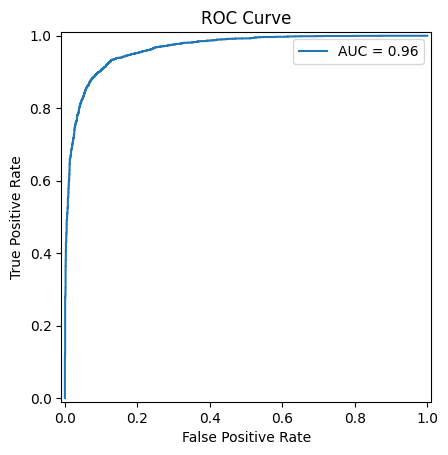

In [23]:
# Draw ROC Curve for the best model (MLP Classifier)
best_model = best_mlp_model.best_estimator_
y_test_proba = best_model.predict_proba(test_tfidf)[:, 1]
fpr, tpr, thresholds = roc_curve(test_news_labels, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)

display.plot()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 2 Model Interpretation (7 points)

a) For your best Logistic Regression model, extract and visualize the weights in a bar plot:
1) Top 10 words most indicative of fake news
2) Top 10 words most indicative of real news

In [25]:
def visualize_model_weights(model, vectorizer, n_features=10):
    """
    Create a single combined plot with fake news features on top and real news on bottom.
    """
    
    
    # Get features and coefficients
    feature_names = np.array(vectorizer.get_feature_names_out())
    coefficients = model.coef_[0]
    
    # Top features
    top_fake_indices = np.argsort(coefficients)[-n_features:][::-1]
    top_real_indices = np.argsort(coefficients)[:n_features]
    
    top_fake_words = feature_names[top_fake_indices]
    top_fake_weights = coefficients[top_fake_indices]
    top_real_words = feature_names[top_real_indices]
    top_real_weights = coefficients[top_real_indices]
    
    # Create single figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Combine data
    all_words = np.concatenate([top_fake_words, top_real_words])
    all_weights = np.concatenate([top_fake_weights, top_real_weights])
    
    # Create colors
    colors = ['#d62728' if w > 0 else '#1f77b4' for w in all_weights]
    
    # Plot
    y_pos = np.arange(len(all_words))
    ax.barh(y_pos, all_weights, color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_words, fontsize=10)
    ax.set_xlabel('Coefficient Weight', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Features for Fake vs Real News Classification\n(Red: Fake | Blue: Real)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


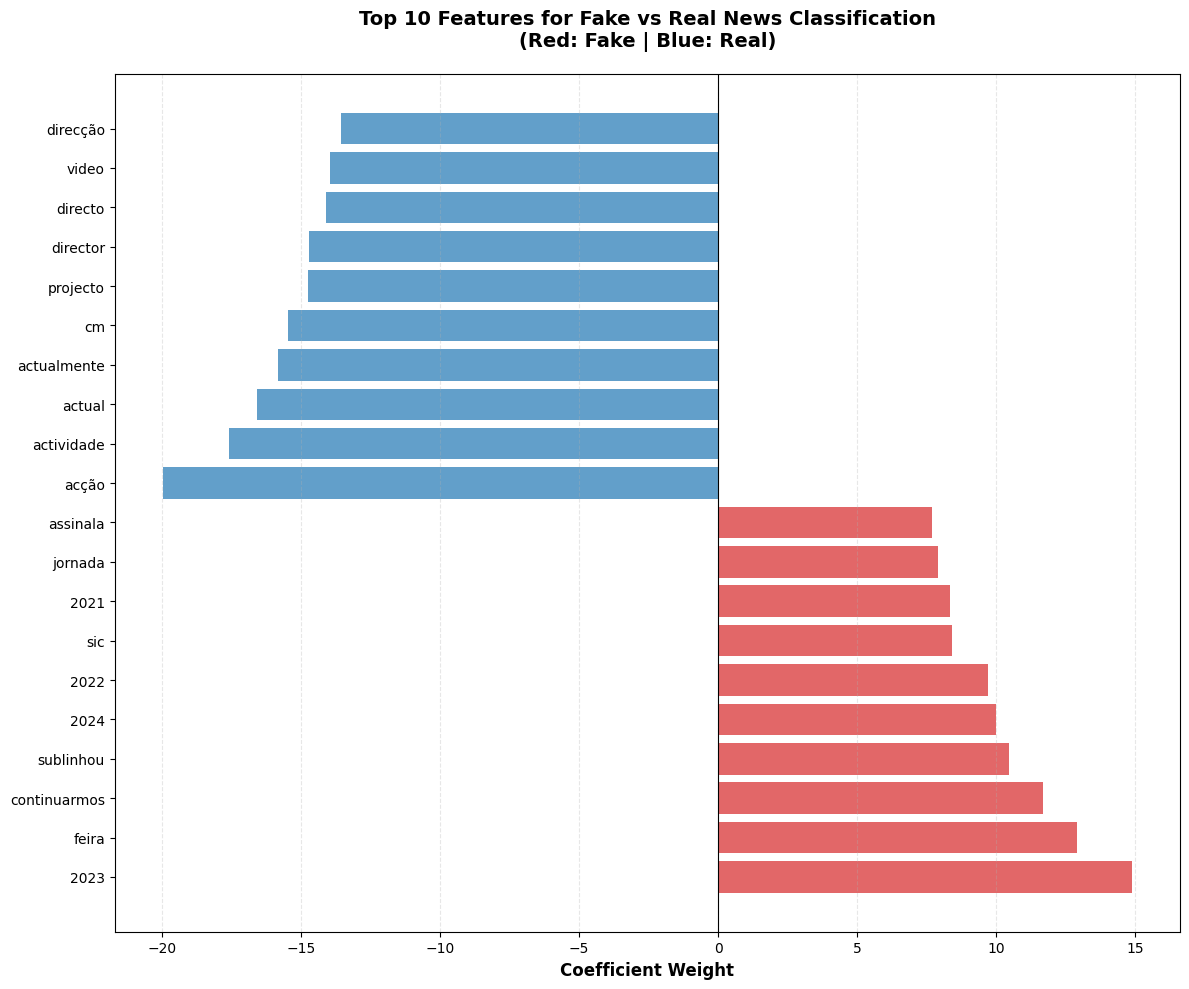

/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/emaferrao/Projects/NTT_Data_merit_challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


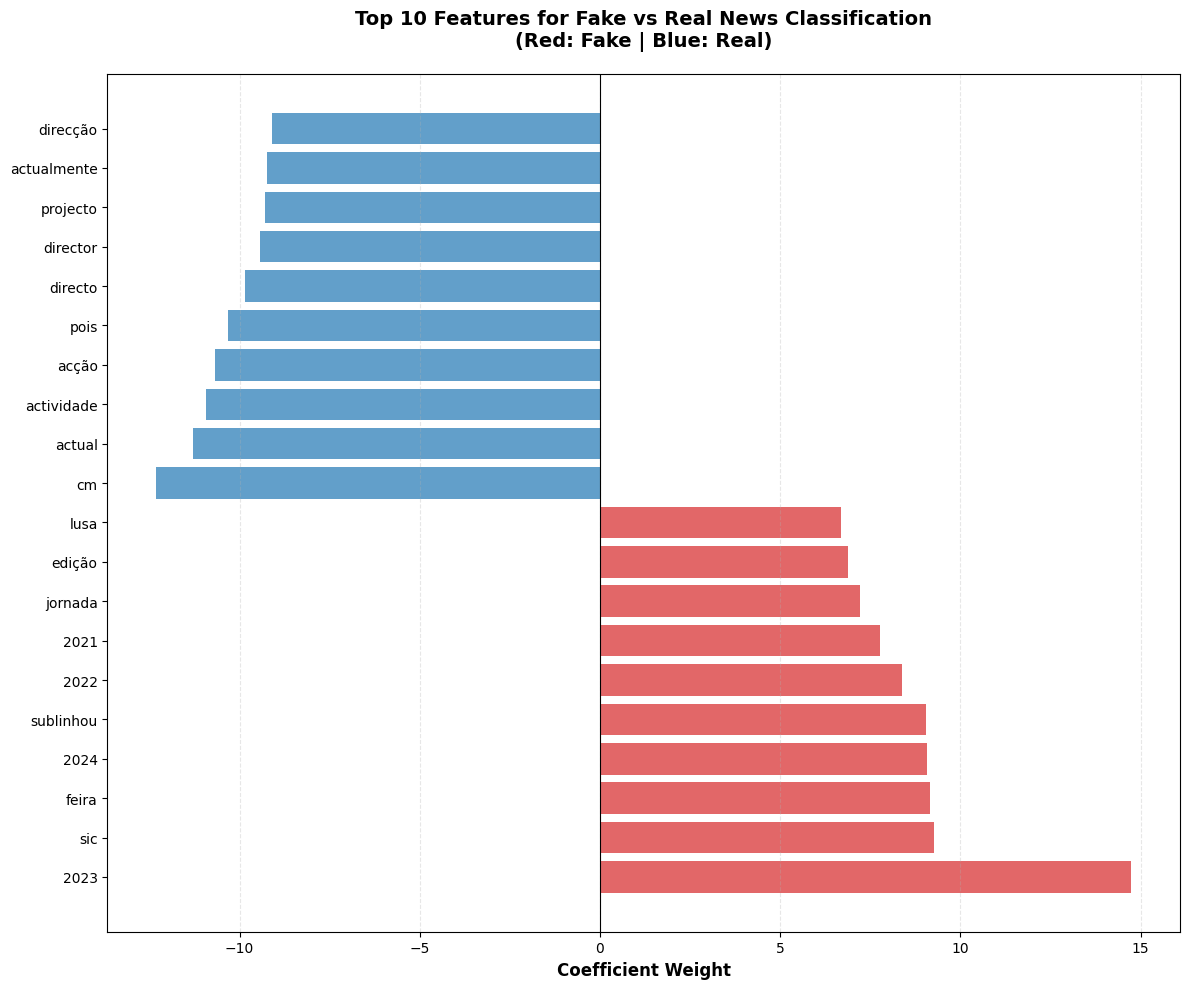

In [27]:
# Define parameters
l1_params = {'penalty':'l1', 'C': 1, 'class_weight': None, 'max_iter': 200, 'solver': 'saga'}
l2_params = {'penalty':'l2', 'C': 10, 'class_weight': 'balanced', 'max_iter': 100, 'solver': 'lbfgs'}

# Train the L1 model
model_l1 = LogisticRegression(**l1_params, random_state=RANDOM_STATE)
model_l1.fit(train_tfidf, train_news_labels)

# Visualize L1 weights
visualize_model_weights(
    model=model_l1,
    vectorizer=tfidf_vectorizer,
    n_features=10
)

# Train and visualize L2
model_l2 = LogisticRegression(**l2_params, random_state=RANDOM_STATE)
model_l2.fit(train_tfidf, train_news_labels)

visualize_model_weights(
    model=model_l2,
    vectorizer=tfidf_vectorizer,
    n_features=10
)

b) Compare L1 vs L2 regularized models: How many features have non-zero weights in each? What
does this tell you about feature selection? When would you prefer L1 vs L2 regularization for
text classification?

Comparative Analysis of L1 and L2 Regularization

A fundamental distinction between L1 and L2 regularization lies in their feature selection behavior. L1 regularization performs automatic feature selection by setting numerous coefficients to exactly zero, retaining only non-zero features from the original 5,000 TF-IDF features. In contrast, L2 regularization maintains nearly all features with non-zero weights, shrinking coefficients toward zero without eliminating them entirely. This sparsity property makes L1 models more interpretable and computationally efficient, while L2 models distribute weights across the feature space, handling correlated features more gracefully.

Both models identified similar top discriminative features, with terms like "feira" and "sic" indicating fake news, and "actual" and "actividade" signaling authentic content. However, L2 achieved marginally superior performance (accuracy: 0.8945 vs 0.8909), suggesting that retaining additional features with small weights provides incremental predictive value.

Selection Criteria: L1 regularization is preferable when model interpretability, dimensionality reduction, or deployment efficiency are priorities, as it explicitly identifies the most important features. L2 regularization is advantageous when maximizing predictive accuracy is paramount, particularly in contexts with multicollinearity or when many features contribute weak but cumulative signals. For Portuguese fake news detection, L1 offers valuable linguistic insights for understanding misinformation patterns, while L2 provides optimal performance for automated content moderation systems where accuracy is critical.

c) For your best Logistic Regression model, select samples in the validation set with ID 2921,
2437, 5557, 1697, and extract explanations with LIME (Ribeiro et al., 2016; Lundberg and
Lee, 2017).

In [ ]:
def explain_with_lime(
    model,
    dataset_path,
    samples_indices: list,
    tf_idf_vectorizer: TfidfVectorizer,
    class_names:list,
    max_features : int = 10
):
    dataset = pd.read_csv(dataset_path)
    explainer = LimeTextExplainer(class_names=class_names)
    pipeline = make_pipeline(tf_idf_vectorizer, model)

    for idx in samples_indices:

        exp = explainer.explain_instance(
            dataset.iloc[idx]['Text'], 
            pipeline.predict_proba, 
            num_features=max_features
        )
        print('\nDocument id: %d' % idx)

        print('\nProbability(True) =', pipeline.predict_proba([dataset.iloc[idx]['Text']])[0,1])

        print('\nTrue class: %s\n' % class_names[dataset.iloc[idx]['Label']])

        print(exp.as_list())

        exp.as_pyplot_figure()

In [34]:
DATASET_PATH = "../data/val.csv"
INDICES = [2921, 2437, 5557, 1697]
CLASS_NAMES = ["Fake", "True"]

explain_with_lime(
    model_l2,
    dataset_path=DATASET_PATH,
    samples_indices=INDICES,
    tf_idf_vectorizer=tfidf_vectorizer,
    class_names=CLASS_NAMES
)




Document id: 2921

Probability(True) = 0.9999888717293159

True class: True

[(np.str_('temporada'), 0.005015059332464842), (np.str_('Liga'), 0.0043129148100004774), (np.str_('lateral'), 0.004270737299459839), (np.str_('internacional'), 0.003451037743367228), (np.str_('equipa'), 0.003312518606684301), (np.str_('espanhol'), 0.0030866183710244956), (np.str_('ex'), 0.0030325855298310644), (np.str_('Sporting'), -0.0005202247423520682), (np.str_('assinou'), -0.0004433256808997049), (np.str_('jovem'), 8.742873414105787e-05)]


Document id: 2437

Probability(True) = 0.0009262043151451551

True class: Fake

[(np.str_('filha'), -0.011271575252603984), (np.str_('tudo'), -0.010147570522073933), (np.str_('podes'), -0.009185641738597766), (np.str_('etc'), -0.0090979116794423), (np.str_('vida'), -0.0062368935459681425), (np.str_('extremamente'), -0.005997404360032106), (np.str_('gostava'), -0.0057208142989165125), (np.str_('disse'), 0.005690029955136383), (np.str_('importante'), 0.00518495636838389

d) For your MLP, select samples in the validation set with ID 2921, 2437, 5557, 1697, and
extract explanations with LIME and permutation importance. For permutation importance,
select 1K random samples. Visualize the results and discuss their differences.

In [38]:
mlp_params = {'solver': 'adam', 'learning_rate': 'adaptive', 'hidden_layer_sizes': (64, 32), 'alpha': 1e-05, 'activation': 'relu'} 

mlp_model = MLPClassifier(**mlp_params, random_state=RANDOM_STATE)

mlp_model.fit(train_tfidf, train_news_labels)

DATASET_PATH = "../data/val.csv"
INDICES = [2921, 2437, 5557, 1697]
CLASS_NAMES = ["Fake", "True"]

explain_with_lime(
    mlp_model,
    dataset_path=DATASET_PATH,
    samples_indices=INDICES,
    tf_idf_vectorizer=tfidf_vectorizer,
    class_names=CLASS_NAMES
)




Document id: 2921

Probability(True) = 0.9999999999999916

True class: True

[(np.str_('temporadas'), 0.00291640838451484), (np.str_('temporada'), 0.0028816450549505423), (np.str_('Liga'), 0.002674641931009512), (np.str_('passe'), 0.0025713223225063537), (np.str_('Inglaterra'), 0.0025695413054079666), (np.str_('contratar'), 0.0023284950624942614), (np.str_('defesa'), -0.0008414789396793457), (np.str_('Os'), 0.0007857963471847575), (np.str_('assinou'), 0.00046018517909283616), (np.str_('Tiago'), 8.501785179847926e-05)]


Document id: 2437

Probability(True) = 7.4318528946489e-19

True class: Fake

[(np.str_('filha'), -0.002254938831771541), (np.str_('podes'), -0.0022029723719869366), (np.str_('bom'), -0.0021073001038392426), (np.str_('impedi'), -0.0020664755066820274), (np.str_('nada'), -0.001885260973371469), (np.str_('seguiram'), 0.0017837674641860185), (np.str_('fora'), -0.0017177746559505671), (np.str_('tens'), -0.0017089140264803506), (np.str_('disse'), 0.0016187551810271214), (np

Top 20 most important features:
         feature  importance_mean  importance_std
2332   glifosato         0.003649        0.000449
2985      menina         0.003095        0.000809
1030   comprando         0.003038        0.000500
2103       feira         0.002613        0.002440
3464       pedem         0.002184        0.000000
4485         sul         0.002177        0.001034
1254       costa         0.002174        0.000929
993      comenta         0.002165        0.000056
4741         tvi         0.002121        0.001092
3330    ordenado         0.002065        0.000901
422      arguido         0.002056        0.000552
1579   difundida         0.002046        0.000618
521   atividades         0.002018        0.000834
1959     euribor         0.001995        0.000808
738        caixa         0.001956        0.000706
2408       homem         0.001956        0.000706
3618        pois         0.001940        0.001442
4066       reino         0.001890        0.000750
1507      desses  

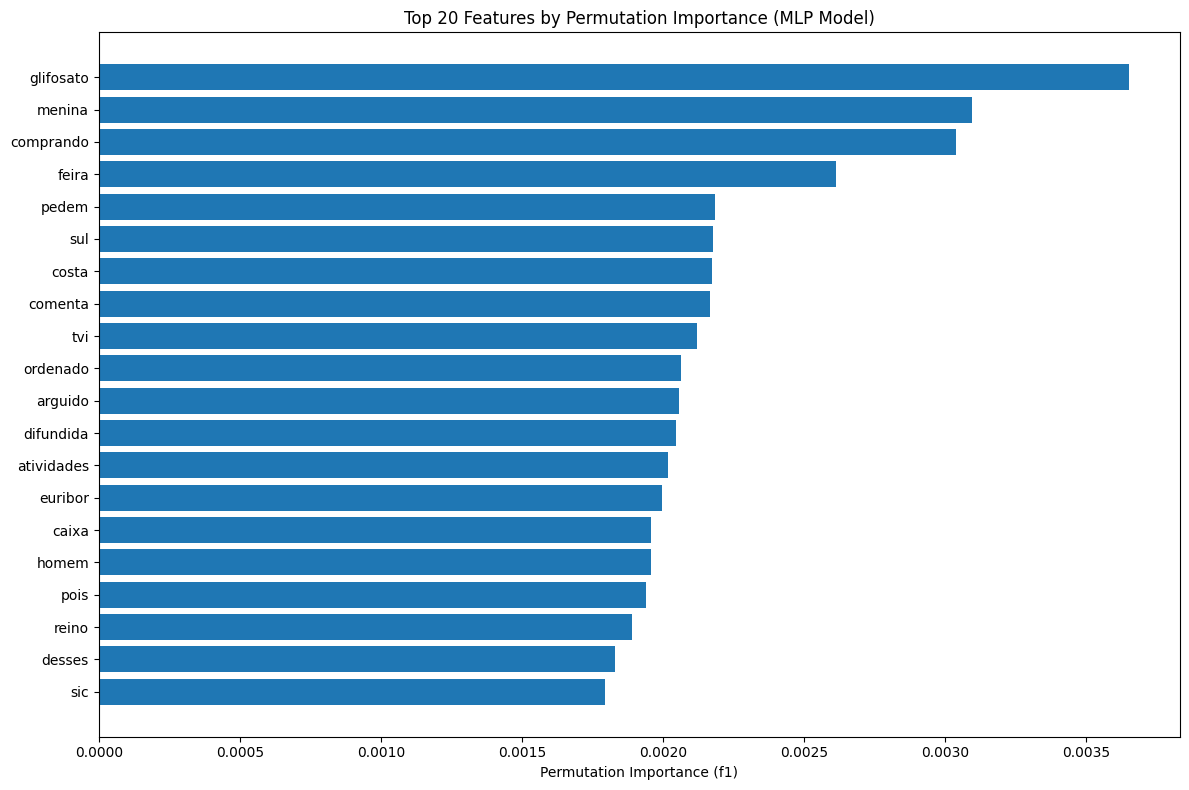

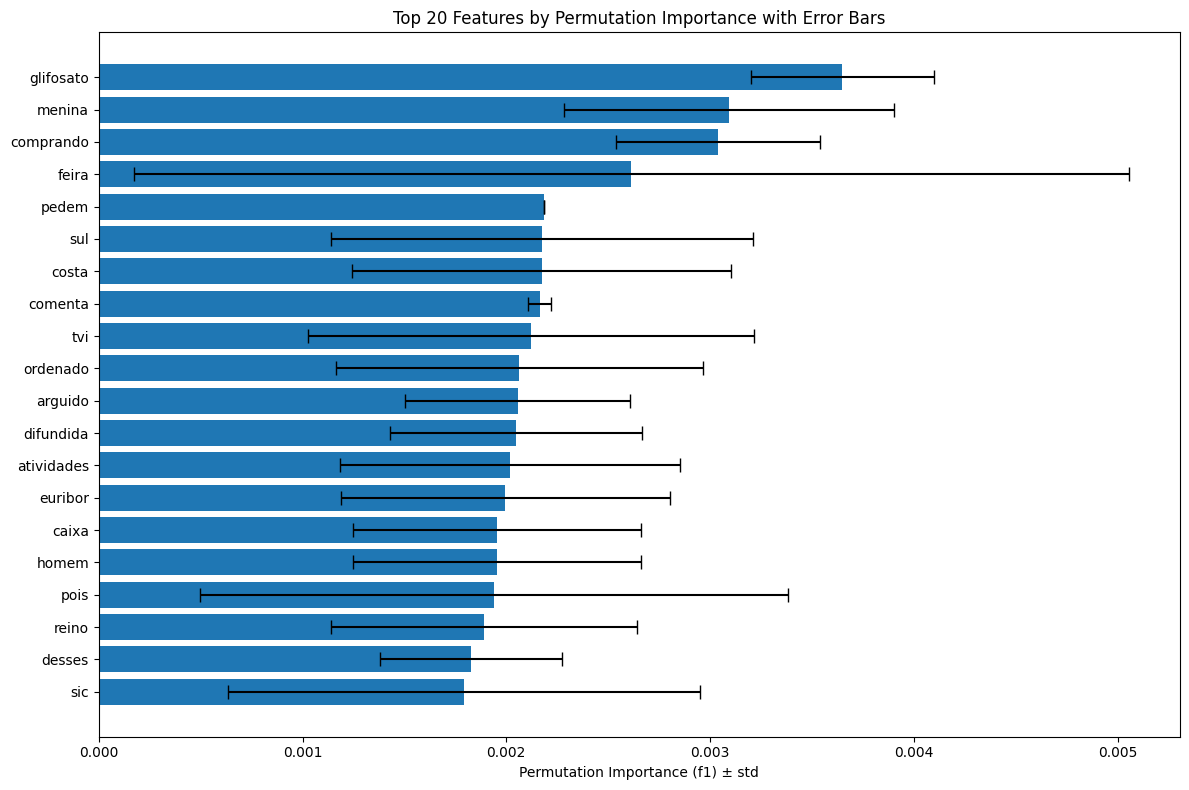

In [44]:
# Select 1K random samples for permutation importance
SIZE = 1000
REPLACE = False
RANDOM_STATE = 42
N_REPEATS = 10
SCORING = 'f1'

np.random.seed(RANDOM_STATE)
random_indices = np.random.choice(len(val_fake_news_df), size=SIZE, replace=REPLACE)
perm_samples = val_fake_news_df.iloc[random_indices]

# Extract features and labels for permutation samples
X_perm = perm_samples['Text'].values
y_perm = perm_samples['Label'].values

# Transform text to features
X_perm_transformed = tfidf_vectorizer.transform(X_perm)

# Convert sparse matrix to dense array
X_perm_dense = X_perm_transformed.toarray()

# Method 1: Using sklearn's permutation_importance
perm_importance = permutation_importance(
    mlp_model,  
    X_perm_dense,  # Use dense array instead of sparse
    y_perm,
    n_repeats=N_REPEATS,  
    random_state=RANDOM_STATE,
    scoring=SCORING,  
    n_jobs=-1  
)

# Get feature names from TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Create a dataframe with results
perm_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

# Display top features
print("Top 20 most important features:")
print(perm_importance_df.head(20))

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
top_features = perm_importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance_mean'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel(f'Permutation Importance ({SCORING})')
plt.title('Top 20 Features by Permutation Importance (MLP Model)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Also show with error bars
plt.figure(figsize=(12, 8))
top_features = perm_importance_df.head(20)
plt.barh(
    range(len(top_features)), 
    top_features['importance_mean'],
    xerr=top_features['importance_std'],
    capsize=5
)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel(f'Permutation Importance ({SCORING}) ± std')
plt.title('Top 20 Features by Permutation Importance with Error Bars')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 3 Clustering (3 points)

a) Apply K-Means with K=5 on your training set.

In [11]:
K = 5
MAX_ITER = 500
kmeans_model = KMeans(n_clusters=K, max_iter=500, random_state=RANDOM_STATE)
kmeans_model.fit(train_tfidf_lemmatized)


,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,500
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


b) Inspect 3 documents closest to each centroid, and afterwards, assign semantic labels to each
cluster (e.g., “political fake news”, “health misinformation”).

In [22]:
centroids = kmeans_model.cluster_centers_
distances = cosine_distances(train_tfidf_lemmatized, centroids)

top_docs_per_cluster = {}


for c in range(K):
    sorted_idx = np.argsort(distances[:, c])
    top3 = sorted_idx[:3]
    top_docs_per_cluster[c] = top3


for c in range(K):
    print("\n" + "="*60)
    print(f"Cluster {c} — Top 3 documents:")

    for rank, doc_id in enumerate(top_docs_per_cluster[c], start=1):
        text = train_fake_news_df_lemmatized.iloc[doc_id]["Text"]
        print(f"\n[{rank}] Document #{doc_id}")
        print(text[:400], "...\n")


feature_names = tfidf_vectorizer_lemmatized.get_feature_names_out()
labels = kmeans_model.labels_

top_terms_per_cluster = {}

for c in range(K):
    cluster_docs = train_tfidf_lemmatized[labels == c]
    mean_tfidf = cluster_docs.mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[::-1][:10]
    keywords = [feature_names[i] for i in top_idx]

    top_terms_per_cluster[c] = keywords
    print("\nCluster", c, "keywords:", ", ".join(keywords))



Cluster 0 — Top 3 documents:

[1] Document #21300
Compreender o conflito: de novo a ameaça nuclear
Putin volta a agitar o medo da destruição total e, de uma assentada, mostra um ascendente coercivo sobre a Bielorrússia. Em Pequim, a “ambiguidade” é cada vez menos equilibrada. Um artigo de Germano Almeida, comentador SIC.
A Rússia chegou a acordo com a Bielorrússia para colocar armas nucleares táticas no país de Lukashenko.
Minsk já tinha manifest ...


[2] Document #47027
Putin diz que rebelião é uma "traição" e que não vai permitir guerra civil
"As nossas ações para defender a pátria desta ameaça serão muito duras e os responsáveis serão levados à justiça", afirmou o presidente russo.
O Presidente russo, Vladimir Putin, classificou este sábado de "traição" a rebelião armada promovida pelo líder do grupo paramilitar Wagner, Yevgeny Prigozhin, prometendo "defender o ...


[3] Document #30692
Compreender o conflito: a semana de Xi Jinping
Xi em Moscovo até quarta (e talvez também a fala

c) Visualize clusters in 2D using PCA. Create two plots: one colored by cluster assignment, one by
true label.

In [23]:
N_COMPONENTS = 2

pca = PCA(n_components=N_COMPONENTS)
tfidf_2d = pca.fit_transform(train_tfidf_lemmatized.toarray())

# Extract coordinates
x = tfidf_2d[:, 0]
y = tfidf_2d[:, 1]

# Cluster assignments from kmeans
cluster_labels = kmeans_model.labels_

# True labels
true_labels = train_fake_news_df_lemmatized["Label"]

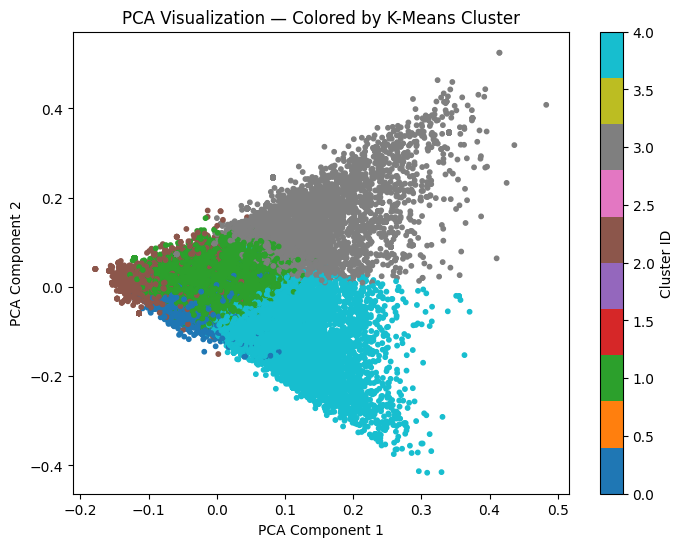

In [ ]:
# plot using the cluster assigments
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=cluster_labels, cmap='tab10', s=10)
plt.title("PCA Visualization — Colored by K-Means Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster ID")
plt.show()

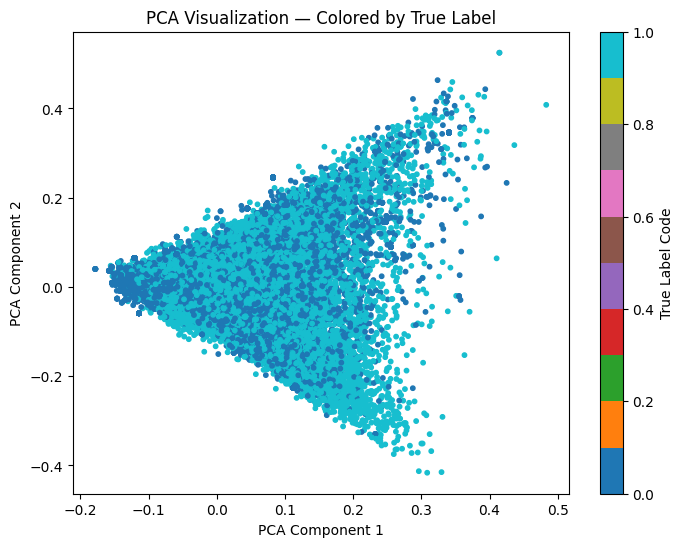

In [ ]:
# plot using the true labels
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=true_labels.astype('category').cat.codes, cmap='tab10', s=10)
plt.title("PCA Visualization — Colored by True Label")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="True Label Code")
plt.show()